# MPhil DIS: S1 Coursework Solution 2025/26

*Nabeel Chaudary*

---
## 1) Plotting Sample Estimates
**10 marks**

### 1(i) plot total sample
- Get hold of your data sample, `sample.csv`, and make a plot of the measured energy, `E`, minus the true energy, `E_0`. This plot should be saved in `figs/Figure1.1.pdf`.

In [2]:
import pandas as pd 

sample_df = pd.read_csv("../sample.csv")
sample_df.head()

,E_true,E_rec
0,20,20.116080
1,20,20.910469
2,20,15.256252
3,20,22.628035
4,20,25.062633


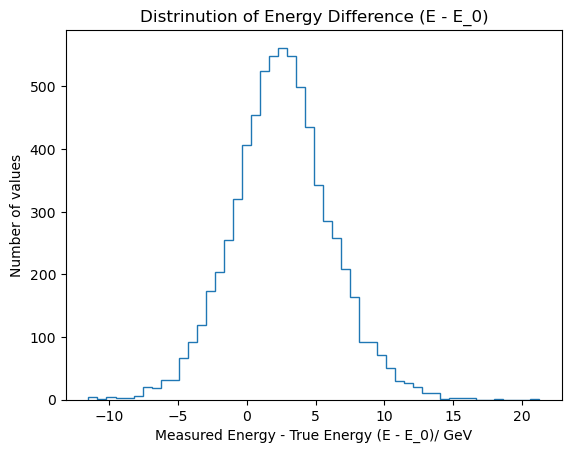

In [3]:
import matplotlib.pyplot as plt
import os

# Dimensions of the plot required.
fig, ax = plt.subplots(figsize=(6.4, 4.8))

# Calculate the energy difference and plot the 
sample_df['E_difference'] = sample_df['E_rec'] - sample_df['E_true']
ax.hist(sample_df['E_difference'], bins=50, histtype="step") 

# Add labels and title
ax.set_xlabel("Measured Energy - True Energy (E - E_0)/ GeV")
ax.set_ylabel("Number of values")
ax.set_title("Distrinution of Energy Difference (E - E_0)")

# Create folder for figures if it doesn't already exist
os.makedirs("../figs", exist_ok=True)

# Save the figure
fig.savefig("../figs/Figure1.1.pdf")

### 1(ii) overlay samples at each $E_0$
- Make a plot which shows the distribution of `E - E_0`, with the histograms for each different value of `E_0` overlaid. This plot should be saved in `figs/Figure1.2.pdf`

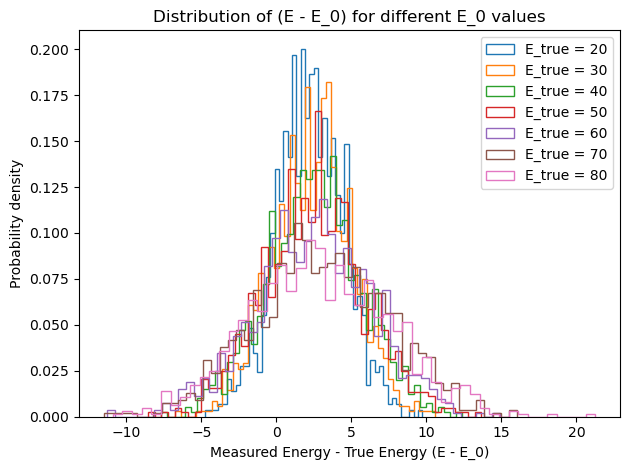

In [4]:
import numpy as np

# example showing the dimensions of the plot required.
fig, ax = plt.subplots(figsize=(6.4, 4.8))

# Get all unique E_0 values
unique_E0 = sample_df["E_true"].unique()

for E0 in unique_E0:

    # Select only rows that correspond to this E0
    sub_df = sample_df[sample_df["E_true"] == E0]

    # Get the E-E0 values
    diff_values = sub_df["E_difference"]

    # Make the histogram
    ax.hist(
        diff_values,
        bins=50,            #number of bins
        histtype="step",
        density=True,      # probability density
        label=f"E_true = {E0}"
    )

# Add labels and title
ax.set_xlabel("Measured Energy - True Energy (E - E_0)")
ax.set_ylabel("Probability density")
ax.set_title("Distribution of (E - E_0) for different E_0 values")
ax.legend()
fig.tight_layout() # Adjust layout to fit labels well

fig.savefig("../figs/Figure1.2.pdf")

### 1(iii) sample estimates
- Produce sample estimates of the mean, $\hat{\mu}_{\rm samp}$, and standard deviation, $\hat{\sigma}_{\rm samp}$, of $E$ at each value of $E_0$. These should be presented along with sample estimates of the error on these estimates (i.e. the standard error on the mean and the standard error on the standard deviation).
- Make two plots (sub-axes of the same figure) showing the points $\hat{\mu}_{\rm samp}$ and $\hat{\sigma}_{\rm samp}$ as a function of $E_0$. This figure should be saved to `figs/Figure1.3.pdf`

In [5]:

# Empty list to store results
results = []

# Go over each E0 value
for E0 in sample_df["E_true"].unique():

    # Select all E_rec values only with this E0
    data = sample_df[sample_df["E_true"] == E0]["E_rec"]

    # Number of samples
    N = len(data)

    # Sample mean
    mu_samp = np.mean(data)

    # Sample standard deviation (ddof=1 for sample std)
    sigma_samp = np.std(data, ddof=1)

    # Standard error on the mean
    SE_mu = sigma_samp / np.sqrt(N)

    # Standard error on the standard deviation
    SE_sigma = sigma_samp / np.sqrt(2*(N-1))

    # Store the values 
    results.append([E0, N, mu_samp, SE_mu, sigma_samp,  SE_sigma])

# Store data in a summary table
summary = pd.DataFrame(results, columns=[
    "E_true", "N", "mu_samp", "SE_mu", "sigma_samp", "SE_sigma"
])

print(summary)

   E_true     N    mu_samp     SE_mu  sigma_samp  SE_sigma
0      20  1000  22.238933  0.070714    2.236165  0.050027
1      30  1000  32.392305  0.083746    2.648283  0.059247
2      40  1000  42.475490  0.099857    3.157760  0.070645
3      50  1000  52.509953  0.105668    3.341508  0.074756
4      60  1000  62.455090  0.122229    3.865221  0.086472
5      70  1000  72.999077  0.139147    4.400211  0.098441
6      80  1000  82.872887  0.148277    4.688922  0.104900


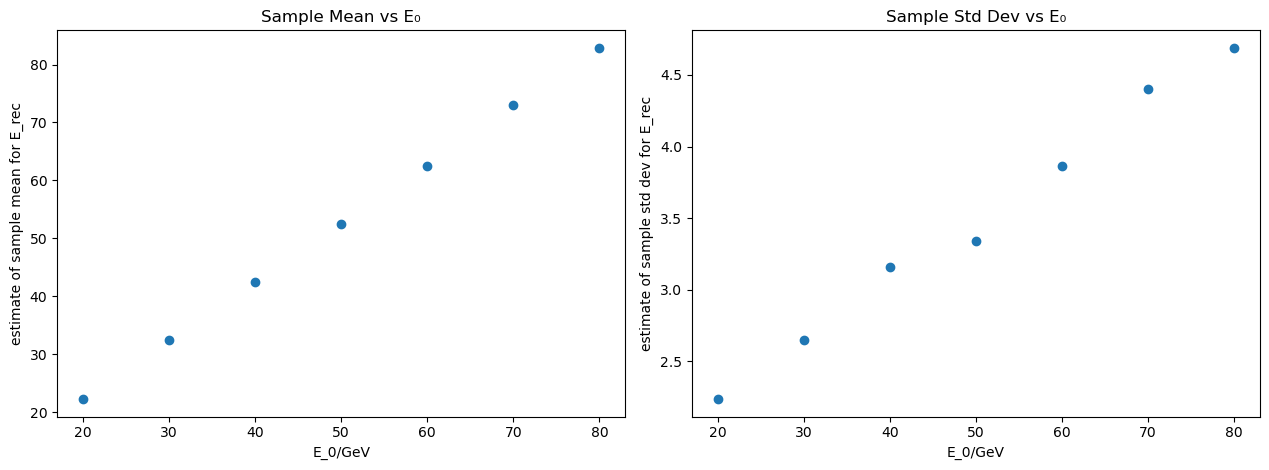

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12.8, 4.8))

# Plot 1: mean vs E_true
ax[0].plot(
    summary["E_true"],
    summary["mu_samp"],
    'o'                         
)

ax[0].set_xlabel("E_0/GeV")
ax[0].set_ylabel("estimate of sample mean for E_rec")
ax[0].set_title("Sample Mean vs E₀")

# Plot 2: std dev vs E_true
ax[1].plot(
    summary["E_true"],
    summary["sigma_samp"],
    'o'                        
)

ax[1].set_xlabel("E_0/GeV")
ax[1].set_ylabel("estimate of sample std dev for E_rec")
ax[1].set_title("Sample Std Dev vs E₀")

plt.tight_layout()

fig.savefig("../figs/Figure1.3.pdf")

### 1(iv) fit trends
- Perform a least squares fit using the energy and width dependence formulas provided in the problem description (at the top of this notebook) to produce estimates (and estimates of the errors on those estimates) for the parameters $\lambda$, $\Delta$, $a$, $b$ and $c$. Be sure to save these determinations for later or write them directly into the `results.json` file
- The previously made plots don't have a particular sensible y-scale. Make two plots (sub-axes of the same figure) showing the points $\hat{\mu}_{\rm samp}$ and $\hat{\sigma}_{\rm samp}$ as a function of $E_0$ **but this time realign the y-scale** so that you plot $\hat{\mu}_{\rm samp} - E_0$ and $\hat{\sigma}_{\rm samp} / E_0$. You should also **overlay the fitted curves** and add error bands ($\pm 1\sigma$) to the curves by bootstrapping. This figure should be saved to `figs/Figure1.4.pdf`

In [82]:
from iminuit import Minuit
from iminuit.cost import LeastSquares
from s1_sol import s1funcs

# x-values: E0
E0 = summary["E_true"].to_numpy()

# Get means values for mean fit
mu_values   = summary["mu_samp"].to_numpy()   # measured sample means
mu_errors   = summary["SE_mu"].to_numpy()     # errors on the means

# Get standard deviation values for width fit
sigma_values = summary["sigma_samp"].to_numpy()  # measured sample widths
sigma_errors = summary["SE_sigma"].to_numpy()    # errors on the widths


# define the model for the mean
def mu_model(E0, lb, dE):
    return lb * E0 + dE

# LeastSquares cost function 
mean_cost = LeastSquares(E0, mu_values, mu_errors, mu_model)

# create a Minuit object with starting guesses
mean_minuit = Minuit(mean_cost, lb=1.0, dE=0.0)

# run the minimisation
mean_minuit.migrad()
mean_minuit.hesse()

# extract best-fit parameters and their errors 
lb       = mean_minuit.values["lb"]
dE       = mean_minuit.values["dE"]
lb_err   = mean_minuit.errors["lb"]
dE_err = mean_minuit.errors["dE"]

print("mean energy fit results:")
print(f"lambda = {lb} ± {lb_err}")
print(f"delta  = {dE} ± {dE_err}")



# define the model for the width
def sigma_model(E0, a, b, c):
    return E0 * np.sqrt((a / np.sqrt(E0))**2 + (b / E0)**2 + c**2)

# LeastSquares cost function 
width_cost = LeastSquares(E0, sigma_values, sigma_errors, sigma_model)

# Minuit object with starting guesses
width_minuit = Minuit(width_cost, a=1.0, b=1.0, c=0.1)

# run the minimisation
width_minuit.migrad()
width_minuit.hesse()

# extract best-fit parameters and their errors
a       = width_minuit.values["a"]
b       = width_minuit.values["b"]
c       = width_minuit.values["c"]
a_err   = width_minuit.errors["a"]
b_err   = width_minuit.errors["b"]
c_err   = width_minuit.errors["c"]

print("\n width fit results:")
print(f"a = {a} ± {a_err}")
print(f"b = {b} ± {b_err}")
print(f"c = {c} ± {c_err}")

# Write values into results.json file
s1funcs.update_results_json("sample_ests",
                   lb, lb_err,
                   dE, dE_err,
                   a, a_err,
                   b, b_err,
                   c, c_err)



mean energy fit results:
lambda = 1.010456648443708 ± 0.002003234896655717
delta  = 2.036854651747957 ± 0.08909892444870879

 width fit results:
a = 0.33160613978954057 ± 0.07300955463196836
b = 1.458129412732927 ± 0.30523560980900366
c = 0.0420256123664001 ± 0.006614628187075628
Updated 'sample_ests' in results.json


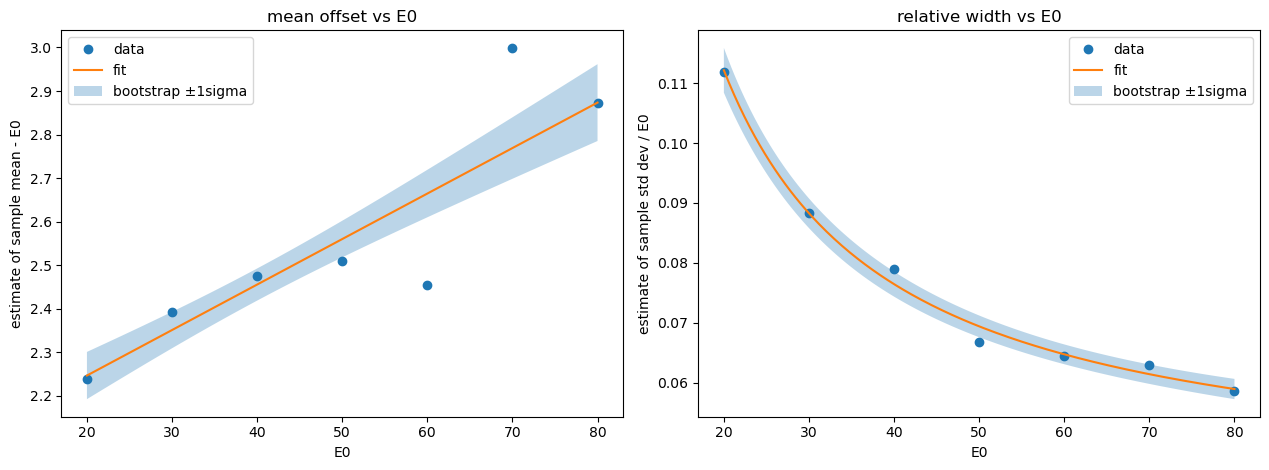

In [101]:
fig, ax = plt.subplots(1, 2, figsize=(12.8, 4.8))

# PART 1: plot estimate of sample mean - E0 against E0 
#       and estimate of sample std dev / E0 against E0
# x-values
E0 = summary["E_true"].to_numpy()
# y-values 
mu_shift    = mu_values - E0
sigma_ratio = sigma_values / E0

# plot data points
ax[0].plot(E0, mu_shift, "o", label="data")
ax[1].plot(E0, sigma_ratio, "o", label="data")

# set labels and titles
ax[0].set_xlabel("E0")
ax[0].set_ylabel("estimate of sample mean - E0")
ax[0].set_title("mean offset vs E0")

ax[1].set_xlabel("E0")
ax[1].set_ylabel("estimate of sample std dev / E0")
ax[1].set_title("relative width vs E0")


# Part 2: overlay the fitted curves
# E0 values for the fits
E_plot = np.linspace(E0.min(), E0.max(), 200)

# fitted curves using best–fit parameters
mu_curve    = mu_model(E_plot, lb, dE) - E_plot
sigma_curve = sigma_model(E_plot, a, b, c) / E_plot

# overlay the fitted curves
ax[0].plot(E_plot, mu_curve, label="fit")
ax[1].plot(E_plot, sigma_curve, label="fit")


# Part 3: add bootstrap error bands (±1sigma bands) to the curves
N_BOOT = 1000  # number of bootstrapped values

# parameters of mean and width models
mean_params  = np.array([lb, dE])
width_params = np.array([a, b, c])

# covariance matrices of parameters for mean and width models
mean_cov  = np.array(mean_minuit.covariance)     
width_cov = np.array(width_minuit.covariance)   

mu_boot_curves    = []
sigma_boot_curves = []

for _ in range(N_BOOT):
    # draw one random parameter set for each model
    lb_bs, dE_bs = np.random.multivariate_normal(mean_params,  mean_cov)
    a_bs,  b_bs, c_bs = np.random.multivariate_normal(width_params, width_cov)

    # compute and save the corresponding curves
    mu_boot_curves.append(mu_model(E_plot, lb_bs, dE_bs) - E_plot)
    sigma_boot_curves.append(sigma_model(E_plot, a_bs, b_bs, c_bs) / E_plot)

#turn into a numpy array to calculate std devs
mu_boot_curves    = np.array(mu_boot_curves)
sigma_boot_curves = np.array(sigma_boot_curves)

# ±1sigma band height at each E_plot point
mu_band    = mu_boot_curves.std(axis=0)
sigma_band = sigma_boot_curves.std(axis=0)

# add shaded bootstrap bands
ax[0].fill_between(
    E_plot,
    mu_curve - mu_band,
    mu_curve + mu_band,
    alpha=0.3,
    label="bootstrap ±1sigma",
)

ax[1].fill_between(
    E_plot,
    sigma_curve - sigma_band,
    sigma_curve + sigma_band,
    alpha=0.3,
    label="bootstrap ±1sigma",
)

# add legends now that all elements are on the axes
ax[0].legend()
ax[1].legend()

plt.tight_layout()
fig.savefig("../figs/Figure1.4.pdf")

---
## 2) Individual Fits
**10 marks**

### 2(i) normal fits
- Now instead of sample estimates for the mean and width, perform and unbinned maximum likelihood fit of the distribution of $E$ at each value of $E_0$ using a normal distribution to determine the mean, $\hat{\mu}_{\rm indiv}$, and width, $\hat{\sigma}_{\rm indiv}$, (as well as their errors) at each $E_0$
- Make two plots (sub-axes of the same figure). The left should show the distribution of $E-E_0$ (with the distribution at each value of $E_0$ overlaid) also overlaying the result of the normal likelihood fits. The right should show the distribution of $E - E_0$ for all values and then overlay the approproiately normalised sum of sub-distributions. This plot should be saved in `figs/Figure2.1.pdf`

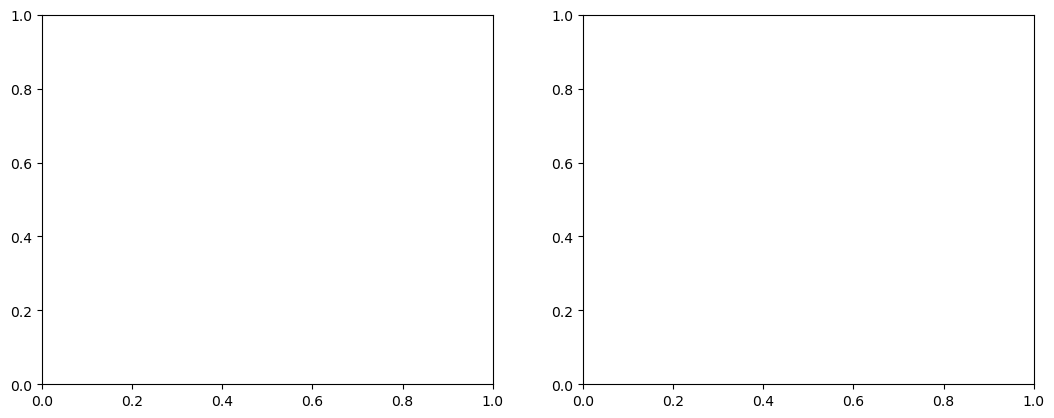

In [110]:
fig, ax = plt.subplots(1, 2, figsize=(12.8, 4.8))

# put your code here

fig.savefig("../figs/Figure2.1.pdf")

### 2(ii) fit trends
- Perform a least squares fit using the energy and width dependence formulas provided in the problem description (at the top of this notebook) to produce estimates (and estimates of the errors on those estimates) for the parameters $\lambda$, $\Delta$, $a$, $b$ and $c$. Be sure to save these determinations for later or write them directly to the `results.json` file.
- Make two plots (sub-axes of the same figure) showing the fitted values $\hat{\mu}_{\rm indiv} - E_0$ and $\hat{\sigma}_{\rm indiv}/E_0$ as a function of $E_0$ **as well as** the fitted curves. You should add an error band ($\pm 1\sigma$) to the curves by bootstrapping. This figure should be saved to `figs/Figure2.2.pdf`

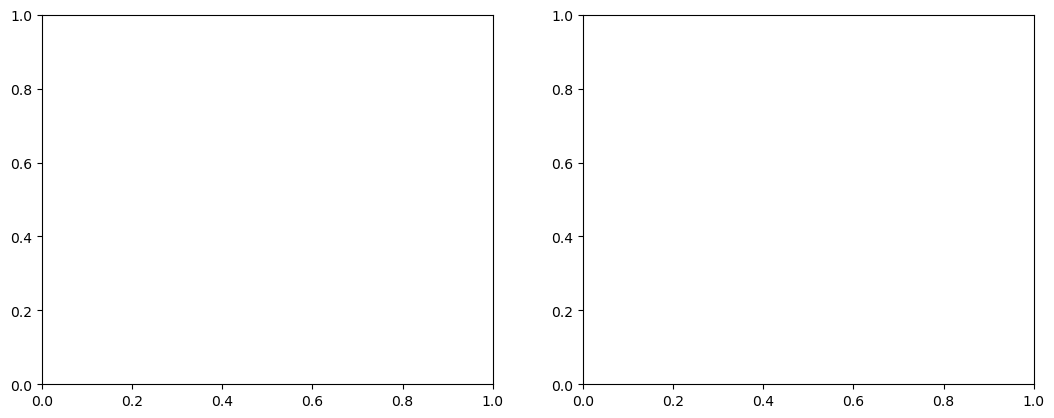

In [111]:
fig, ax = plt.subplots(1, 2, figsize=(12.8, 4.8))

# put your code here

fig.savefig("../figs/Figure2.2.pdf")

---
## 3.) Simultaneous Fit
**10 marks**

### 3(i) the simultaneous likelihood
- Write down an equation for the simultaneous likelihood in which all points are fitted together, i.e. directly fitting the sample for $\lambda$, $\Delta$, $a$, $b$ and $c$
- Appropriately code this and perform an unbinned maximum likelihood fit to all $E_0$ bins simultaneously, to produce estimates (and estimates of the errors on those estimates) for the parameters $\lambda$, $\Delta$, $a$, $b$ and $c$. Be sure to save these determinations for later or write them directly to the `results.json` file.
- Make two plots (sub-axes of the same figure) showing the fitted curves for $\mu_E$ and $\sigma_E$ as a function of $E_0$. You should add an error band ($\pm 1\sigma$) to the curves by bootstrapping. You should stick to the convention of plotting $\mu_E - E_0$ and $\sigma_E / E_0$ as a function of $E_0$. This figure should be saved to `figs/Figure3.1.pdf`

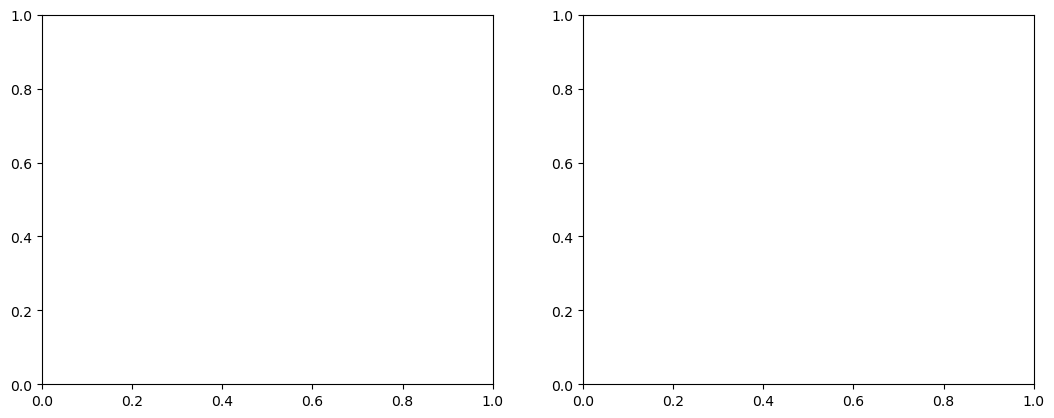

In [112]:
fig, ax = plt.subplots(1, 2, figsize=(12.8, 4.8))

# put your code here

fig.savefig("../figs/Figure3.1.pdf")

### 3(ii) saving the results
- At this point you should have estimates of the five parameters, $\{\lambda, \Delta, a, b, c\}$, (along with their errors), using three different methods: "a sample estimate", "individual fits" and "a simultaneous fit".
- Ensure these are now saved into the `results.json` file in the correct format

In [113]:
from s1_sol import example
#example.make_results_json("../results.json")

### 3(iii) comparing the results
- Make a plot which shows the estimate and error of each parameter, labelling the different estimation types with different colours.
- The parameters may well have rather different values so you will need to think carefully about how you present this information in a sensible way.
- You should save this in a file called `figs/Figure3.2.pdf`

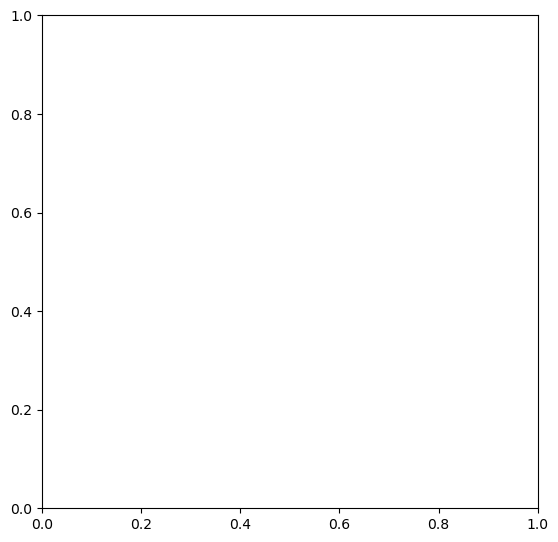

In [114]:
fig, ax = plt.subplots(figsize=(6.4, 6.4))

# put your code here

fig.savefig("../figs/Figure3.2.pdf")

---
## 4.) Bootstrap entire sample
**20 marks**
- Run a non-parameteric bootstrap on the entire analysis using sampling with replacement (and 2500 samples). For reference on my machine this takes ~1 min)
- Produce a figure with 5 subfigures which shows histograms of the bootstrapped values with each method overlaid as a separate colour. You should save this plot in a file called `figs/Figure4.1.pdf`
- Produce a second figure which is the same in style to the plot produced in 3(iii) above this time using the bootstrapped sample to estimate the value and error. You should overlay both sets of points (i.e. the values and errors from parts 1-3 and also the bootstrapped values and errors from part 4). You should save this plot in a file called `figs/Figure4.2.pdf`

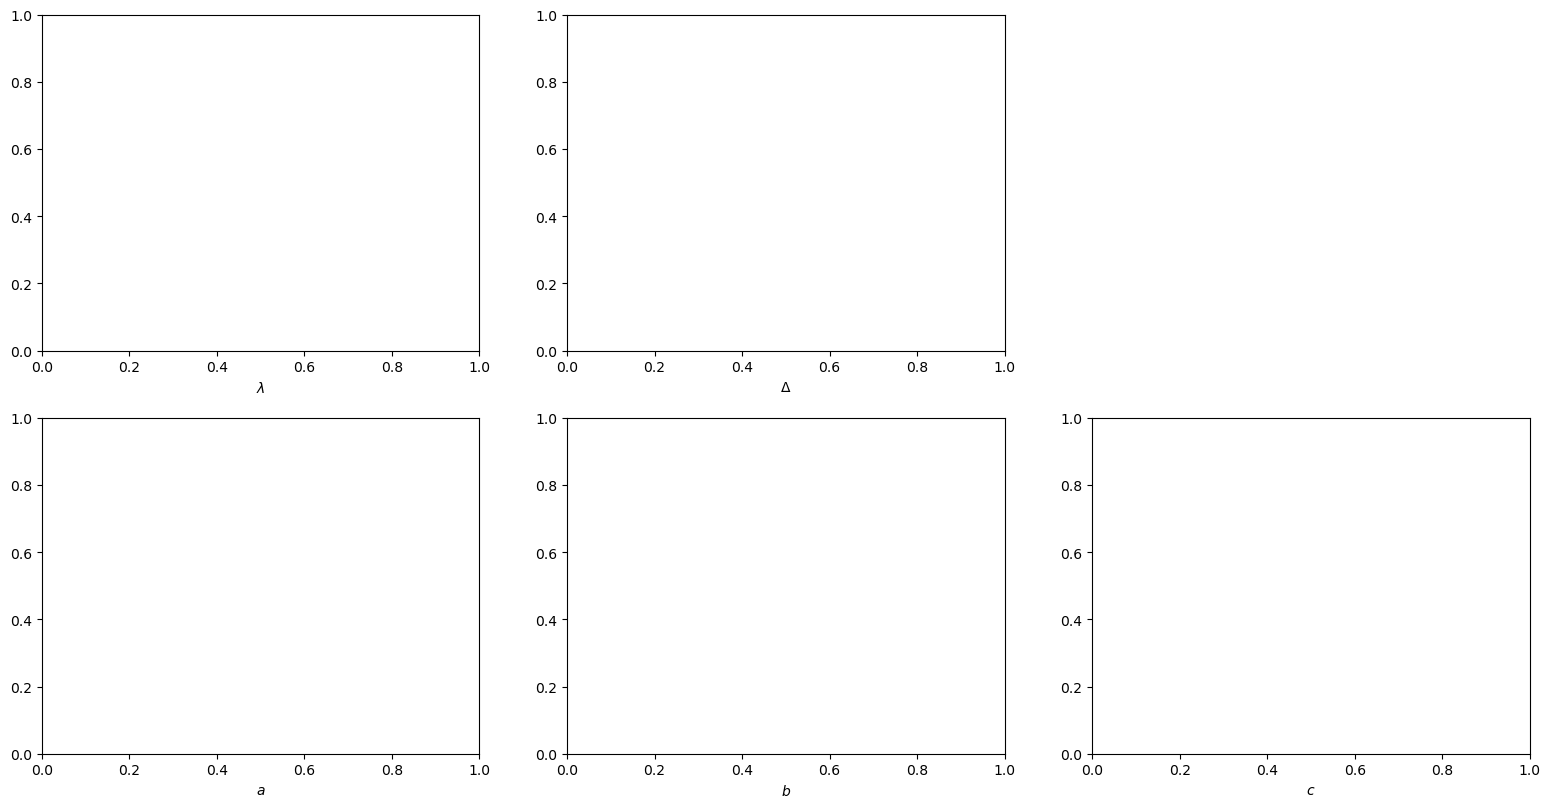

In [115]:
fig, ax = plt.subplots(2, 3, figsize=(19.2, 9.6))

# put your code here
ax[0,0].set_xlabel("$\lambda$")
ax[0,1].set_xlabel("$\Delta$")
ax[0,2].set_visible(False)
ax[1,0].set_xlabel("$a$")
ax[1,1].set_xlabel("$b$")
ax[1,2].set_xlabel("$c$")

fig.savefig("../figs/Figure4.1.pdf")

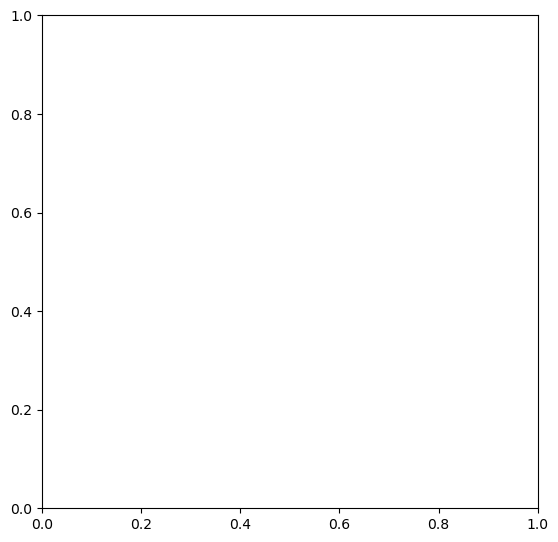

In [116]:
fig, ax = plt.subplots(figsize=(6.4, 6.4))

# put your code here

fig.savefig("../figs/Figure4.2.pdf")

---
## 5.) Discussion of Results
**20 marks**

- Please briefly discuss your findings in no more than 500 words. Do you find what you would naively expect? Can you comment on any discrepancies you see? Would you redesign the analysis in any way?